# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the seminar notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

bash: ../xvfb: No such file or directory


In [ ]:
# Install gymnasium if you didn't
!pip install gymnasium[toy_text,classic_control]

state vector dim = 4
n_actions = 2


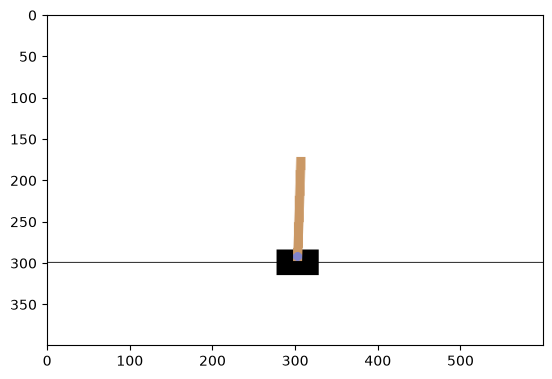

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v1", render_mode="rgb_array").env

env.reset(seed=42)
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

In [4]:
env.reset()[0]

array([-0.04058227,  0.04756223,  0.02611397,  0.02860643], dtype=float32)

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [5]:
list(range(n_actions))

[0, 1]

In [13]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation="relu",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


In [14]:
s, _ = env.reset()
agent.predict_proba([s])[0]

array([0.51044393, 0.48955607])

In [15]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [16]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.04621161  0.00917374  0.00911472 -0.01351661]
 [ 0.04639509 -0.18607773  0.00884439  0.2820281 ]
 [ 0.04267353 -0.3813247   0.01448495  0.57748735]
 [ 0.03504704 -0.18640874  0.0260347   0.2894025 ]
 [ 0.03131886  0.00833247  0.03182274  0.00504301]]
actions: [0, 0, 1, 1, 0]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [17]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    elite_indices = np.where(rewards_batch >= np.percentile(rewards_batch, percentile))[0]
    elite_states = []
    elite_actions = []
    for i in elite_indices:
        elite_states.extend(states_batch[i])
        elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[8, 4])
    fig.suptitle("mean reward = %.3f, threshold = %.3f" % (mean_reward, threshold))

    ax1.plot(list(zip(*log))[0], label="Mean rewards")
    ax1.plot(list(zip(*log))[1], label="Reward thresholds")
    ax1.legend()
    ax1.grid()

    ax2.hist(rewards_batch, range=reward_range)
    ax2.vlines([threshold], [0], [100], label="percentile", color="red")
    ax2.legend()
    ax2.grid()

    handle = getattr(show_progress, "_handle", None)
    if handle is None:
        show_progress._handle = display(fig, display_id=True)
    else:
        handle.update(fig)

    plt.close(fig)

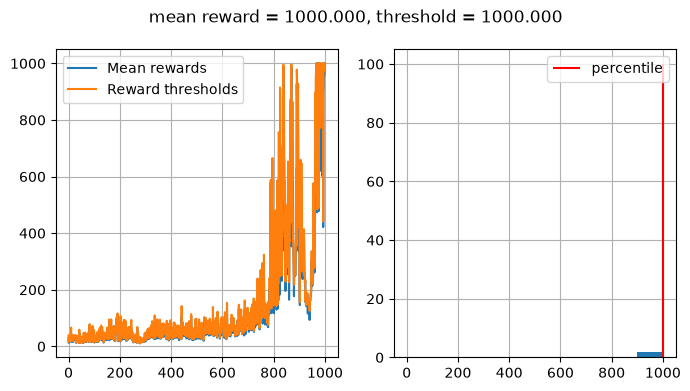

You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You may stop training now via KeyboardInterrupt.
You Win! You m

In [19]:
n_sessions = 1000
percentile = 85
log = []

for i in range(1000):
    # generate new sessions
    sessions = [generate_session(env=env, agent=agent) for _ in range(n_actions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>
    agent = agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")



### Student comment

Честно, сказать не получилось сделать что то с количеством параметров типа $32\times32$, что еще хоть как то похоже на обучение

С таким количеством параметров как у меня $(128 \times 128)$, можно в целом заучить просто всю выборку и то я в конце куда то ушел с оптимума

Хотя видео траектории выглядят неплохо

# Results

In [22]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./videos/CartPole-v1",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(5)]


In [23]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos/CartPole-v1").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -1000 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (0.1 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (0.1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


```<Describe what you did here>```

Весь код в одной ячейке пункты 1.1 и 1.2 далее там же и пояснения

python 3.12.8 | gymnasium 1.3.0 | numpy 2.5.3
start state: 252 | info: {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}
n_states=500, n_actions=6


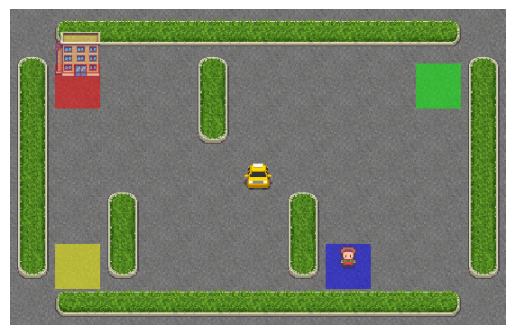

In [33]:
import sys
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"python {sys.version.split()[0]} | gymnasium {gym.__version__} | numpy {np.__version__}")

SEED = 1
np.random.seed(SEED)  # чтобы графики воспроизводились между запусками

env = gym.make("Taxi-v4", render_mode="rgb_array")
obs, info = env.reset(seed=SEED)
print("start state:", obs, "| info:", info)

plt.imshow(env.render())
plt.axis("off");

n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"n_states={n_states}, n_actions={n_actions}")

def initialize_policy(n_states, n_actions):
    policy = np.ones((n_states, n_actions)) / n_actions

    return policy

policy = initialize_policy(n_states, n_actions)
assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1.0 / n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

def generate_session(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        #<YOUR CODE: sample action from policy>
        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


def show_progress(rewards_batch, log, percentile, policy=None, elapsed=None,
                  reward_range=(-990, 10), plot=True):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    solved = np.mean(np.asarray(rewards_batch) > 0)  # доля эпизодов с положительной наградой

    # энтропия стратегии: показывает, насколько стратегия ещё исследует,
    # а не схлопнулась в детерминизм
    if policy is None:
        entropy = np.nan
    else:
        entropy = -(policy * np.log(policy + 1e-12)).sum(axis=1).mean()

    log.append([mean_reward, threshold, solved, entropy])

    if not plot:
        return

    mean_rewards, thresholds, solved_rates, entropies = (list(x) for x in zip(*log))

    fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(13, 4))

    tail = f" | {elapsed:.1f} s/iter" if elapsed is not None else ""
    fig.suptitle(
        f"iter {len(log)} | mean = {mean_reward:.1f} | threshold = {threshold:.1f}"
        f" | solved = {solved:.0%}" + tail
    )

    ax1.plot(mean_rewards, label="Mean rewards")
    ax1.plot(thresholds, label="Reward thresholds")
    ax1.axhline(7.9, color="green", ls="--", lw=1, label="оптимум (~7.9)")
    ax1.axhline(0, color="gray", ls=":", lw=1)
    ax1.legend()
    ax1.grid()

    ax2.plot(solved_rates, color="tab:orange", label="Доля успешных эпизодов")
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid()
    handles = ax2.get_lines()
    if not np.all(np.isnan(entropies)):
        ax3 = ax2.twinx()
        ax3.plot(entropies, color="tab:purple", label="Энтропия стратегии")
        ax3.set_ylim(bottom=0)
        handles += ax3.get_lines()
    ax2.legend(handles, [h.get_label() for h in handles], loc="upper left")

    ax4.hist(rewards_batch, range=reward_range, bins=20)
    ax4.axvline(threshold, color="red", label="percentile")
    ax4.set_ylim(0, len(rewards_batch))
    ax4.legend()
    ax4.grid()

    fig.tight_layout()

    if len(log) == 1:              # новый прогон — новый вывод
        show_progress._handle = display(fig, display_id=True)
    else:
        show_progress._handle.update(fig)

    plt.close(fig)

def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)
    (elites, ) = np.where(rewards_batch >= reward_threshold)
    
    elite_states = []
    elite_actions = []
    for i in elites:
        elite_states.extend(states_batch[i])
        elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    #<YOUR CODE: set probabilities for actions given elite states & actions>
    # Don't forget to set 1/n_actions for all actions in unvisited states.
    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    new_policy[np.where(new_policy.sum(axis=1) == 0)] = 1
    new_policy = new_policy / new_policy.sum(axis=1, keepdims=True)

    return new_policy

from time import perf_counter


def train_cem(env, n_sessions=250, percentile=25, learning_rate=0.5,
              n_iterations=100, verbose=True):
    """Обучить табличную стратегию кросс-энтропийным методом.

    Args:
        env: среда gymnasium.
        n_sessions: сколько эпизодов играем на каждой итерации.
        percentile: какой процент худших эпизодов отбрасываем.
        learning_rate: скорость обновления стратегии, от 0 до 1.
        n_iterations: максимальное число итераций.
        verbose: рисовать ли графики прогресса.

    Returns:
        Пара (log, policy): история обучения и итоговая стратегия.
    """
    policy = initialize_policy(n_states, n_actions)
    log = []

    for i in range(n_iterations):
        t0 = perf_counter()

        sessions = [generate_session(env, policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile
        )
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        elapsed = perf_counter() - t0
       
        show_progress(rewards_batch, log, percentile, policy=policy,
                      elapsed=elapsed, plot=verbose)

        if np.mean(rewards_batch) > 0:
            print(f"Решено за {i + 1} итераций!")
            break

    return log, policy

### 1.1

Давайте просто запустим сетку экспериментов по `percentile` и `n_sessions`. `lr` придется оставить фиксированным дабы мы могли как то рисовать все в две оси

Поскольку количество шагов обновления стратегии у разных `n_sessions` разное, будем это учитывать и количество самих итераций сведем к новой величине `episode_budget`

1. Изначальные тесты на `lr=0.5 & episode_budget=15_000` выглядели неплохо [homeworks/1/cem_results_lr_5.pkl](1/cem_results_lr_5.pkl), но с `n_sessions = 500|1000` видно было что им не хватает времени, а более маленькие конфигурации приближаются к оптимуму, но не дотягивают.
2. Я решил увеличить сразу оба параметра `lr=0.75 & episode_budget=30_000`, и уже в таком случае сессия `500 и 1000` смогли показать `mean_reward > 0` [homeworks/1/cem_results_lr_75_episode_budget_30k.pkl](1/cem_results_lr_75_episode_budget_30k.pkl)
3. Было заметно, что перцентили `>=50` выкидывают часть нужных особей и стратегия западает в локальный оптимум, поэтому я решил провести еще одну итерацию обучения, сменив набор `PCTS = [25, 50, 60, 70, 80, 90]` на `[5, 10, 15, 25, 35]`
    
    Её результаты ниже и в [homeworks/1/cem_results_lr_75_episode_budget_30k.pkl](1/cem_results_lr_75_episode_budget_30k.pkl)

In [28]:
import numpy as np
import gymnasium as gym
from joblib import Parallel, delayed


def run_cem(seed, n_sessions, percentile, lr, episode_budget=15_000):
    np.random.seed(seed)
    env = gym.make("Taxi-v4")
    env.reset(seed=seed)
    policy = initialize_policy(n_states, n_actions)

    rec = []
    for i in range(episode_budget // n_sessions):
        sessions = [generate_session(env, policy) for _ in range(n_sessions)]
        s_b, a_b, r_b = zip(*sessions)
        el_s, el_a = select_elites(s_b, a_b, r_b, percentile)
        policy = lr * get_new_policy(el_s, el_a) + (1 - lr) * policy

        rec.append((
            (i + 1) * n_sessions,
            np.mean(r_b),
            np.mean(np.asarray(r_b) > 0),
            -(policy * np.log(policy + 1e-12)).sum(1).mean(),
            len(np.unique(el_s)) / n_states,
        ))

    keys = ["episodes", "mean", "solved", "entropy", "coverage"]
    return dict(zip(keys, np.asarray(rec).T))


PCTS, NSESS, SEEDS, LR, BUDGET = [5, 15, 25, 35], [100, 250, 500, 1000], [0, 1, 2], 0.75, 30_000

In [ ]:
jobs = [(p, n, s) for p in PCTS for n in NSESS for s in SEEDS]
out = Parallel(n_jobs=-1, verbose=5)(delayed(run_cem)(s, n, p, LR, BUDGET) for p, n, s in jobs)

runs = {}
for (p, n, _), r in zip(jobs, out):
    runs.setdefault((p, n), []).append(r)

In [25]:
import pickle

In [ ]:
with open("1/cem_results_lr_75_pctsv2.pkl", "wb") as f:
    pickle.dump(runs, f)

In [26]:
with open("1/cem_results_lr_75_pctsv2.pkl", "rb") as f:
    runs = pickle.load(f)

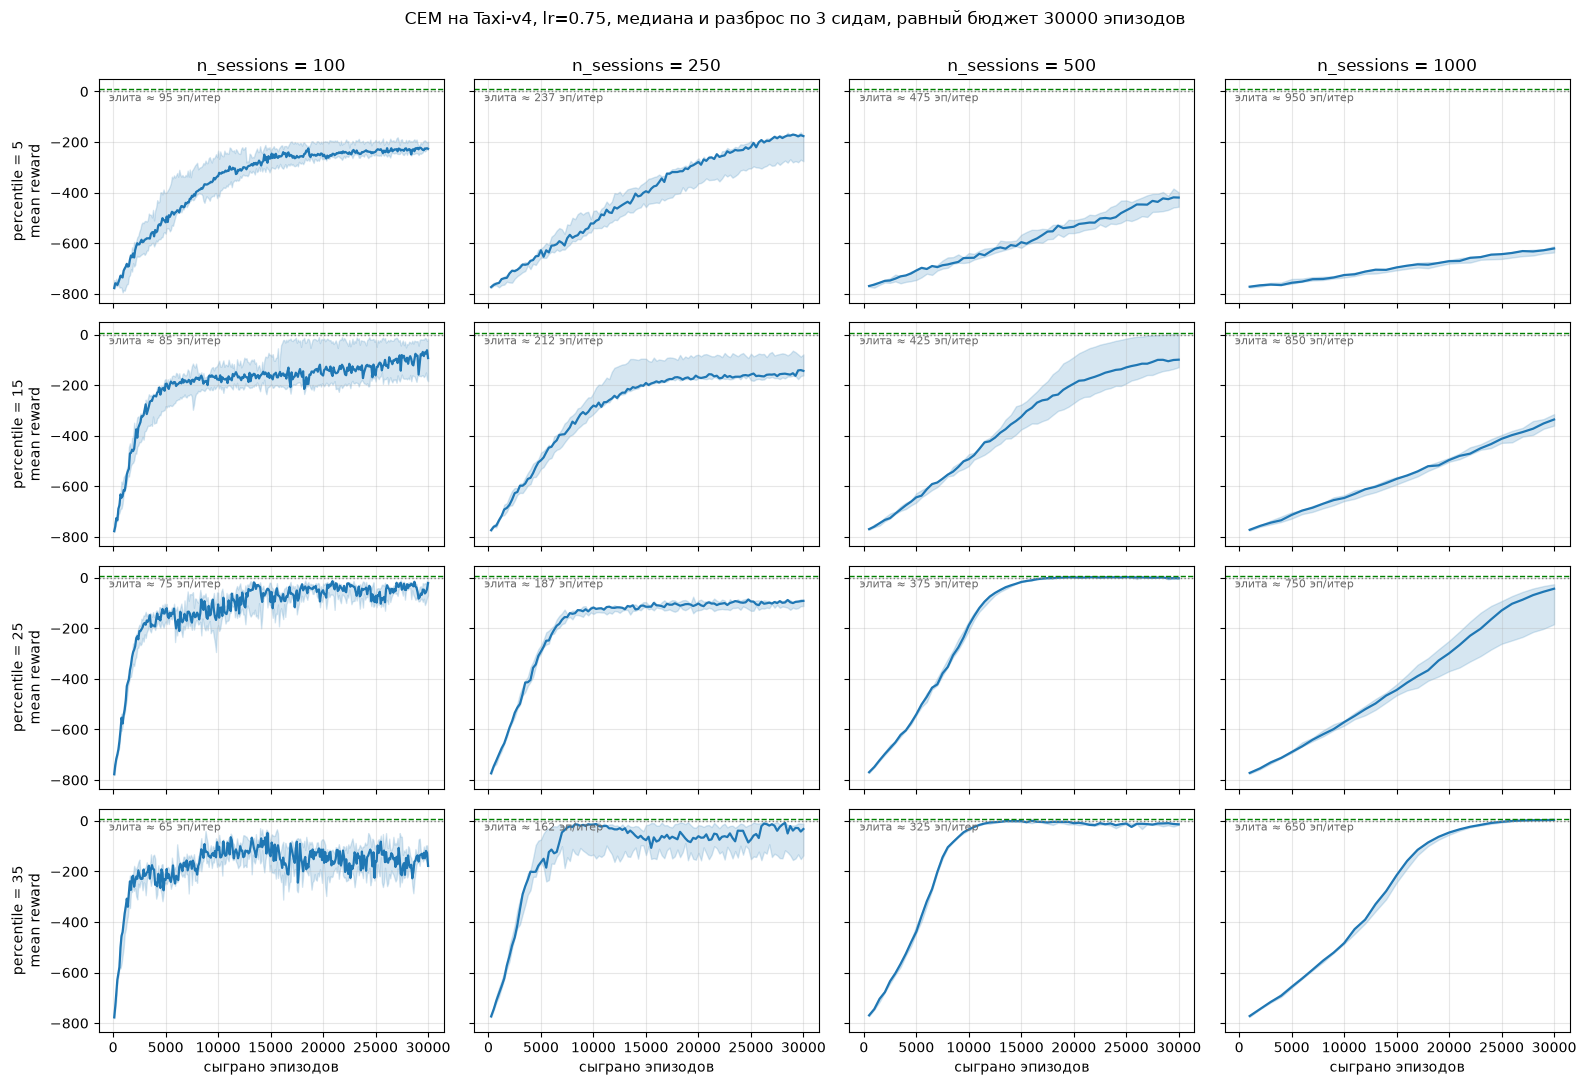

In [29]:
fig, axes = plt.subplots(len(PCTS), len(NSESS), figsize=(4 * len(NSESS), 2.7 * len(PCTS)),
                         sharex=True, sharey=True)

for r, p in enumerate(PCTS):
    for c, n in enumerate(NSESS):
        ax, rs = axes[r, c], runs[(p, n)]
        ep = rs[0]["episodes"]
        curves = np.stack([x["mean"] for x in rs])

        ax.fill_between(ep, curves.min(0), curves.max(0), alpha=0.18, color="tab:blue")
        ax.plot(ep, np.median(curves, 0), color="tab:blue", lw=1.6)
        ax.axhline(0, color="gray", ls=":", lw=1)
        ax.axhline(7.9, color="green", ls="--", lw=1)
        ax.grid(alpha=0.3)
        ax.text(0.03, 0.94, f"элита ≈ {int(n * (1 - p / 100))} эп/итер",
                transform=ax.transAxes, va="top", fontsize=8, color="dimgray")

        if r == 0:
            ax.set_title(f"n_sessions = {n}")
        if c == 0:
            ax.set_ylabel(f"percentile = {p}\nmean reward")
        if r == len(PCTS) - 1:
            ax.set_xlabel("сыграно эпизодов")

fig.suptitle(f"CEM на Taxi-v4, lr={LR}, медиана и разброс по {len(SEEDS)} сидам, "
             f"равный бюджет {BUDGET} эпизодов", y=1.0)
fig.tight_layout()

/var/folders/95/vz8dngcs5y1dy2l562rxw9_r0000gn/T/ipykernel_1847/1231305396.py:11: RuntimeWarning: All-NaN slice encountered
  speed   = np.array([[np.nanmedian([eps_to_solve(r) for r in runs[(p, n)]]) for n in NSESS] for p in PCTS])


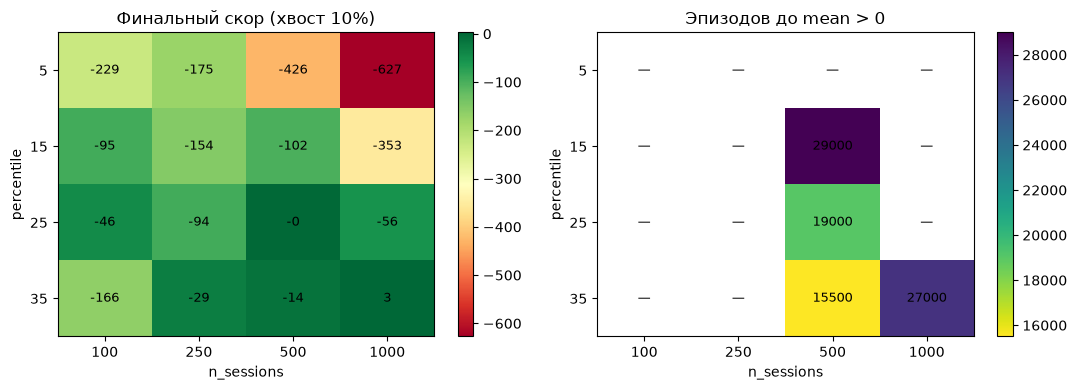

In [30]:
mean_avg_reward_threshold = 0
def tail_score(r, frac=0.1):
    k = max(1, int(len(r["mean"]) * frac))
    return r["mean"][-k:].mean()

def eps_to_solve(r):
    hit = r["mean"] > mean_avg_reward_threshold
    return r["episodes"][np.argmax(hit)] if hit.any() else np.nan

quality = np.array([[np.median([tail_score(r) for r in runs[(p, n)]]) for n in NSESS] for p in PCTS])
speed   = np.array([[np.nanmedian([eps_to_solve(r) for r in runs[(p, n)]]) for n in NSESS] for p in PCTS])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, M, ttl, cmap, fmt in [(axes[0], quality, "Финальный скор (хвост 10%)", "RdYlGn", "{:.0f}"),
                              (axes[1], speed, f"Эпизодов до mean > {mean_avg_reward_threshold}", "viridis_r", "{:.0f}")]:
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(NSESS)), NSESS)
    ax.set_yticks(range(len(PCTS)), PCTS)
    ax.set_xlabel("n_sessions")
    ax.set_ylabel("percentile")
    ax.set_title(ttl)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, "—" if np.isnan(v) else fmt.format(v),
                    ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax)
fig.tight_layout()

Я не нашел какой то золотой ключик, видно, что мы либо не успеваем сходиться, либо теряем нужных элитные траектории и начинаем расходиться, не считая те прогоны, которые вообще до 0 не доходят

Опять же выглядит так, что все закрывывается принципом - чем больше тем лучше, но время тоже хочется экономить 

### Results of Taxi

* Поставим `5` вместо `0` `if np.mean(rewards_batch) > 0:`
* И порог на solved `np.mean(np.asarray(rewards_batch) > 0)`

In [35]:
def train_cem(env, n_sessions=250, percentile=25, learning_rate=0.5,
              n_iterations=100, verbose=True):
    """Обучить табличную стратегию кросс-энтропийным методом.

    Args:
        env: среда gymnasium.
        n_sessions: сколько эпизодов играем на каждой итерации.
        percentile: какой процент худших эпизодов отбрасываем.
        learning_rate: скорость обновления стратегии, от 0 до 1.
        n_iterations: максимальное число итераций.
        verbose: рисовать ли графики прогресса.

    Returns:
        Пара (log, policy): история обучения и итоговая стратегия.
    """
    policy = initialize_policy(n_states, n_actions)
    log = []

    for i in range(n_iterations):
        t0 = perf_counter()

        sessions = [generate_session(env, policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile
        )
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        elapsed = perf_counter() - t0
       
        show_progress(rewards_batch, log, percentile, policy=policy,
                      elapsed=elapsed, plot=verbose)

        if np.mean(rewards_batch) > 5 and np.mean(np.asarray(rewards_batch) > 0) > 0.95:
            print(f"Решено за {i + 1} итераций!")
            break

    return log, policy

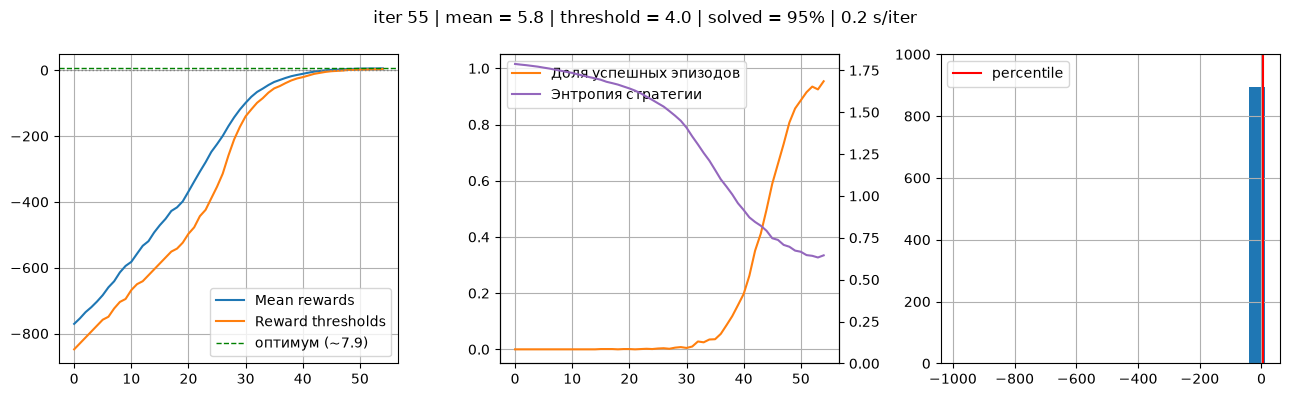

Решено за 55 итераций!


In [36]:
n_iterations = 300
n_sessions = 1000
percentile = 20
learning_rate = 0.75
log = []


env = gym.make("Taxi-v4")
s, _ = env.reset()

log, policy = train_cem(env, n_sessions=n_sessions, percentile=percentile,
                        learning_rate=learning_rate, n_iterations=n_iterations)

Награда за эпизод в среднем перевалила желаемое значение, однако решаем мы все еще не 100% траекторий

Вполне возможно, дальше бы мы снова стали расходиться. Заданный мной огромный разммер $n\_session \times percentile$ как я понимаю, просто позволяет нам не забывать(не терять) разнообразие траекторий и мы всегда остаемся на плаву. Если мы в какой то момент теряем часть пространства элит с какой то траекторией, которая покарывает поведение на конкретном участке дороги (часть пространства состояний), то потом не факт, что мы еще раз выйдем на такую же траекторию.

In [39]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("Taxi-v4", render_mode="rgb_array"),
    video_folder="./videos/Taxi-v4",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, policy) for _ in range(10)]


In [40]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos/Taxi-v4").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-2]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (0.3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 0.5 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (0.1 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (0.2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (0.2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

### 2.1

Взял `MountainCar-v0`.

1. **Нормализация входа.** Позиция в `[-1.2, 0.6]`, скорость в `[-0.07, 0.07]` — без масштабирования сеть практически не видит скорость.

2. **Отбор элиты по вспомогательному скору.** Вместо награды считаю `R + shaping * max_pos`, где `max_pos` — максимальная достигнутая позиция за эпизод. Пока никто не доезжает, это единственный источник различий между сессиями: отбираются те, кто сильнее раскачался. Как только доля успешных переваливает за 90%, `max_pos` у всех выходит на ~0.5, бонус вырождается в константу — отключаю явно, и отбор возвращается к истинной награде. То есть шейпинг влияет только на старт и не искажает итоговую метрику.

Динамика получается двухфазной. Первые [N] итераций `solved = 0%` и `mean = -1000`, но `max_pos` монотонно ползёт вверх — это единственная живая метрика на этом отрезке. Затем за 2-3 итерации доля успешных прыгает с нуля до 100%, а награда с -1000 до ~-200. Дальше `solved` упирается в потолок и перестаёт что-либо показывать: награда в MountainCar это просто `-1` за шаг, так что `mean = -200` означает «доезжает всегда, но за 200 шагов». Вся оставшаяся оптимизация — это сокращение длины эпизода.


In [47]:
import numpy as np, gymnasium as gym
from collections import deque
from sklearn.neural_network import MLPClassifier

n_actions = 3
OBS_MID   = np.array([-0.3, 0.0], dtype=np.float32)
OBS_SCALE = np.array([0.9, 0.07], dtype=np.float32)
norm_obs = lambda s: (np.asarray(s, dtype=np.float32) - OBS_MID) / OBS_SCALE


def make_agent(hidden=(256, 256), lr=1e-3):
    agent = MLPClassifier(hidden_layer_sizes=hidden, activation="tanh",
                          solver="adam", learning_rate_init=lr,
                          warm_start=False, max_iter=1)
    agent.partial_fit(norm_obs(np.zeros((n_actions, 2))),
                      np.arange(n_actions), classes=np.arange(n_actions))
    return agent


def rollout_batch(envs, agent, t_max=1000, greedy=False):
    n = len(envs)
    S = np.zeros((n, t_max, 2), dtype=np.float32)
    A = np.zeros((n, t_max), dtype=np.int64)
    lengths, rewards = np.full(n, t_max), np.zeros(n)
    solved = np.zeros(n, dtype=bool)

    obs = np.stack([env.reset()[0] for env in envs]).astype(np.float32)
    max_pos, alive = obs[:, 0].copy(), np.ones(n, dtype=bool)

    for t in range(t_max):
        idx = np.flatnonzero(alive)
        if idx.size == 0:
            break
        p = agent.predict_proba(norm_obs(obs[idx]))
        a = p.argmax(1) if greedy else \
            (p.cumsum(1) < np.random.rand(idx.size, 1)).sum(1).clip(0, n_actions - 1)

        S[idx, t], A[idx, t] = obs[idx], a
        for k, i in enumerate(idx):
            o, r, term, trunc, _ = envs[i].step(int(a[k]))
            obs[i], rewards[i] = o, rewards[i] + r
            max_pos[i] = max(max_pos[i], o[0])
            if term or trunc:
                alive[i], solved[i], lengths[i] = False, term, t + 1

    return dict(S=[S[i, :lengths[i]] for i in range(n)],
                A=[A[i, :lengths[i]] for i in range(n)],
                L=lengths, R=rewards, max_pos=max_pos, solved=solved)

In [48]:
def select_elites(buffer, percentile, shaping=0.0, n_bins=8, max_transitions=200_000):
    idx = [(bi, si) for bi, b in enumerate(buffer) for si in range(len(b["R"]))]
    score = np.array([buffer[bi]["R"][si] + shaping * buffer[bi]["max_pos"][si]
                      for bi, si in idx])
    start = np.array([buffer[bi]["S"][si][0, 0] for bi, si in idx])
    bins = np.clip(((start + 0.6) / 0.2 * n_bins).astype(int), 0, n_bins - 1)

    keep = np.zeros(len(idx), bool)
    for bn in np.unique(bins):
        m = bins == bn
        if m.sum() >= 4:
            keep[m] = score[m] > np.percentile(score[m], percentile)
    if not keep.any():
        keep[np.argsort(score)[-max(1, len(idx) // 10):]] = True

    sel = [idx[k] for k in np.flatnonzero(keep)]
    X = np.concatenate([buffer[bi]["S"][si] for bi, si in sel])
    y = np.concatenate([buffer[bi]["A"][si] for bi, si in sel])
    if len(X) > max_transitions:
        sub = np.random.choice(len(X), max_transitions, replace=False)
        X, y = X[sub], y[sub]
    return X, y, np.percentile(score, percentile)


def fit_agent(agent, X, y, n_epochs=3, batch_size=1024):
    Xn = norm_obs(X)
    classes = np.arange(n_actions)
    for _ in range(n_epochs):
        order = np.random.permutation(len(Xn))
        for s in range(0, len(order), batch_size):
            b = order[s:s + batch_size]
            agent.partial_fit(Xn[b], y[b], classes=classes)

In [49]:
def train_deep_cem(n_sessions=100, percentile=70, n_iterations=40, t_max=1000,
                   lr=1e-3, shaping=1000.0, buffer_size=4, seed=0):
    np.random.seed(seed)
    envs = [gym.make("MountainCar-v0", max_episode_steps=t_max) for _ in range(n_sessions)]
    agent = make_agent(lr=lr)
    buffer, log = deque(maxlen=buffer_size), []

    for i in range(n_iterations):
        b = rollout_batch(envs, agent, t_max=t_max)
        buffer.append(b)

        cur_shaping = shaping if b["solved"].mean() < 0.9 else 0.0
        X, y, thr = select_elites(buffer, percentile, cur_shaping)
        fit_agent(agent, X, y)

        log.append(dict(mean=b["R"].mean(), solved=b["solved"].mean(),
                        best=b["R"].max(), max_pos=b["max_pos"].mean()))
        print(f"iter {i+1:3d} | mean {b['R'].mean():8.1f} | best {b['R'].max():7.1f} "
              f"| solved {b['solved'].mean():5.0%} | max_pos {b['max_pos'].mean():+.3f} "
              f"| elite {len(X):6d}")

    for e in envs:
        e.close()
    return agent, log


def evaluate(agent, n_episodes=100, t_max=1000):
    envs = [gym.make("MountainCar-v0", max_episode_steps=t_max) for _ in range(n_episodes)]
    b = rollout_batch(envs, agent, t_max=t_max, greedy=True)
    for e in envs:
        e.close()
    return b["R"].mean(), b["R"].std(), b["solved"].mean()

### 2.1

In [50]:
agent, log = train_deep_cem(n_sessions=400, percentile=85, n_iterations=50)
print(evaluate(agent))

iter   1 | mean   -996.8 | best  -596.0 | solved    1% | max_pos -0.152 | elite  61728
iter   2 | mean   -970.6 | best  -498.0 | solved   17% | max_pos +0.045 | elite 108978
iter   3 | mean   -925.6 | best  -446.0 | solved   38% | max_pos +0.217 | elite 142361
iter   4 | mean   -903.5 | best  -411.0 | solved   43% | max_pos +0.263 | elite 172388
iter   5 | mean   -753.0 | best  -287.0 | solved   84% | max_pos +0.440 | elite 142436
iter   6 | mean   -701.4 | best  -334.0 | solved   90% | max_pos +0.466 | elite 125731
iter   7 | mean   -590.1 | best  -276.0 | solved   98% | max_pos +0.502 | elite 106737
iter   8 | mean   -555.4 | best  -211.0 | solved   99% | max_pos +0.508 | elite  94052
iter   9 | mean   -483.3 | best  -199.0 | solved  100% | max_pos +0.512 | elite  88383
iter  10 | mean   -446.7 | best  -201.0 | solved  100% | max_pos +0.512 | elite  80530
iter  11 | mean   -384.9 | best  -209.0 | solved  100% | max_pos +0.513 | elite  72662
iter  12 | mean   -365.6 | best  -201.0 | s

In [51]:
import sys
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
from gymnasium.wrappers import RecordVideo


def play_one(env, agent, t_max=1000, greedy=True):
    obs, _ = env.reset()
    total = 0.0
    for _ in range(t_max):
        p = agent.predict_proba(norm_obs(obs[None]))[0]
        a = int(p.argmax()) if greedy else int(np.random.choice(n_actions, p=p))
        obs, r, term, trunc, _ = env.step(a)
        total += r
        if term or trunc:
            break
    return total


with RecordVideo(
    env=gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=1000),
    video_folder="./videos/MountainCar-v0/1.1",
    episode_trigger=lambda n: True,
) as env_monitor:
    rewards = [play_one(env_monitor, agent) for _ in range(5)]

print(rewards)

/Users/bogdan/Projects/SB-RL-2026/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/bogdan/Projects/SB-RL-2026/homeworks/videos/MountainCar-v0/1.1 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[-111.0, -108.0, -150.0, -145.0, -106.0]


In [52]:
video_paths = sorted(Path("videos/MountainCar-v0/1.1").glob("*.mp4"))
video_path = video_paths[-1]

if "google.colab" in sys.modules:
    data_url = "data:video/mp4;base64," + b64encode(video_path.read_bytes()).decode()
else:
    data_url = str(video_path)

HTML(f'<video width="640" height="480" controls><source src="{data_url}" type="video/mp4"></video>')

На видео выше, что задача выполнена, ее неоптимальность в такой большой амплитуде раскачки

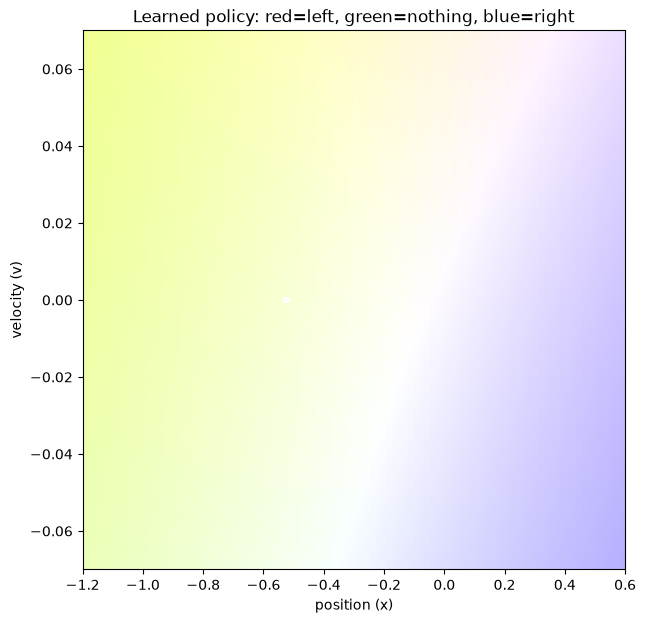

In [53]:
def visualize_mountain_car(env, agent):
    core = env.unwrapped
    xs = np.linspace(core.min_position, core.max_position, 100)
    vs = np.linspace(-core.max_speed, core.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = agent.predict_proba(norm_obs(grid_flat))
    probs = probs.reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    probs = probs / probs.max(axis=-1, keepdims=True)

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(probs, extent=(core.min_position, core.max_position,
                             -core.max_speed, core.max_speed), aspect="auto")
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    b = rollout_batch([env], agent, t_max=10_000, greedy=True)
    states  = b["S"][0]
    actions = b["A"][0]
    ax.plot(states[:, 0], states[:, 1], color="white", lw=1)

    for (x, v), a in zip(states[::3], actions[::3]):
        if a in (0, 2):
            ax.arrow(x, v, -0.1 if a == 0 else 0.1, 0,
                     color="white", head_length=0.02)
            
with gym.make("MountainCar-v0").env as env:
    visualize_mountain_car(env, make_agent())


### 2.2

Три пункта задания меряю по отдельности, потому что ускоряют они разное.

1. **Батч-прогон вместо посессионного.** Не из списка в задании, но даёт основной множитель. Вместо `n_sessions × t_max` вызовов `predict_proba` с батчем из одного состояния — `t_max` вызовов с батчем до `n_sessions`, среды шагаются синхронно, завершившиеся выбывают.

2. **joblib.** Среды создаются внутри воркера. Обязательная деталь: без `threadpool_limits(1)` воркеры дерутся за ядра через BLAS и параллельная версия оказывается медленнее последовательной.

3. **Переиспользование сессий (`buffer_size=4`).** Порог и обучающая выборка считаются по объединённому пулу последних четырёх итераций. Отбор это не ломает: по мере роста стратегии старые сессии сами опускаются ниже порога и выпадают из элиты.

Результаты на графиках ниже

In [ ]:
import os
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits


def _worker(agent, n_envs, t_max, seed):
    np.random.seed(seed)
    envs = [gym.make("MountainCar-v0", max_episode_steps=t_max) for _ in range(n_envs)]
    with threadpool_limits(limits=1):
        out = rollout_batch(envs, agent, t_max=t_max)
    for e in envs:
        e.close()
    return out

def rollout_naive(envs, agent, t_max=1000, greedy=False):
    """Базовая версия: сессии по очереди, один forward на каждый шаг."""
    S, A, L, R, MP, SOLVED = [], [], [], [], [], []

    for env in envs:
        obs, _ = env.reset()
        states, actions, total = [], [], 0.0
        max_pos, term = obs[0], False

        for _ in range(t_max):
            p = agent.predict_proba(norm_obs(obs[None]))[0]
            a = int(p.argmax()) if greedy else int(np.random.choice(n_actions, p=p))
            states.append(obs.copy())
            actions.append(a)
            obs, r, term, trunc, _ = env.step(a)
            total += r
            max_pos = max(max_pos, obs[0])
            if term or trunc:
                break

        S.append(np.array(states, dtype=np.float32))
        A.append(np.array(actions, dtype=np.int64))
        L.append(len(states))
        R.append(total)
        MP.append(max_pos)
        SOLVED.append(term)

    return dict(S=S, A=A, L=np.array(L), R=np.array(R),
                max_pos=np.array(MP), solved=np.array(SOLVED))

def rollout_parallel(agent, n_sessions, t_max, n_jobs=4):
    per = n_sessions // n_jobs
    parts = Parallel(n_jobs=n_jobs)(
        delayed(_worker)(agent, per, t_max, np.random.randint(1 << 30))
        for _ in range(n_jobs))
    return dict(
        S=[s for p in parts for s in p["S"]],
        A=[a for p in parts for a in p["A"]],
        L=np.concatenate([p["L"] for p in parts]),
        R=np.concatenate([p["R"] for p in parts]),
        max_pos=np.concatenate([p["max_pos"] for p in parts]),
        solved=np.concatenate([p["solved"] for p in parts]),
    )

In [ ]:
from time import perf_counter

def train_deep_cem(n_sessions=100, percentile=70, n_iterations=40, t_max=1000,
                   lr=1e-3, shaping=1000.0, buffer_size=4, seed=0,
                   parallel=False, batched=True, n_jobs=4, agent=None):
    np.random.seed(seed)
    agent = agent if agent is not None else make_agent(lr=lr)
    buffer, log = deque(maxlen=buffer_size), []
    envs = None if parallel else [gym.make("MountainCar-v0", max_episode_steps=t_max)
                                  for _ in range(n_sessions)]
    t_start = perf_counter()

    for i in range(n_iterations):
        if parallel:
            b = rollout_parallel(agent, n_sessions, t_max, n_jobs)
        elif batched:
            b = rollout_batch(envs, agent, t_max=t_max)
        else:
            b = rollout_naive(envs, agent, t_max=t_max)   # «default version»

        buffer.append(b)
        cur_shaping = shaping if b["solved"].mean() < 0.9 else 0.0
        X, y, thr = select_elites(buffer, percentile, cur_shaping)
        fit_agent(agent, X, y)

        log.append(dict(t=perf_counter() - t_start, episodes=(i + 1) * n_sessions,
                        mean=b["R"].mean(), solved=b["solved"].mean()))
    return agent, log

In [ ]:

VARIANTS = {
    "default (по сессии)":  dict(batched=False, buffer_size=1),
    "+ батч-прогон":        dict(batched=True,  buffer_size=1),
    "+ joblib":             dict(parallel=True, buffer_size=1),
    "+ reuse(4)":           dict(parallel=True, buffer_size=4),
}
runs = {k: train_deep_cem(n_iterations=25, seed=0, **v)[1] for k, v in VARIANTS.items()}

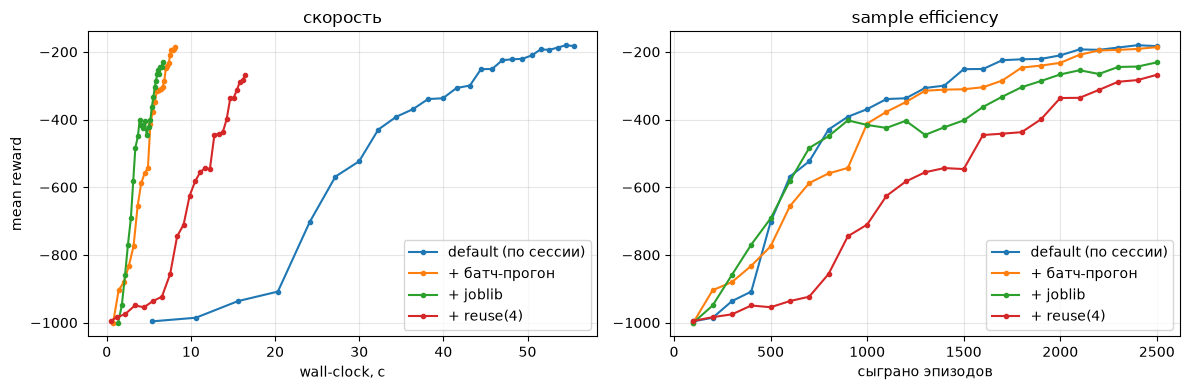

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for name, lg in runs.items():
    a1.plot([x["t"] for x in lg], [x["mean"] for x in lg], marker=".", label=name)
    a2.plot([x["episodes"] for x in lg], [x["mean"] for x in lg], marker=".", label=name)
a1.set_xlabel("wall-clock, с"); a1.set_ylabel("mean reward"); a1.set_title("скорость")
a2.set_xlabel("сыграно эпизодов"); a2.set_title("sample efficiency")
for a in (a1, a2):
    a.grid(alpha=0.3); a.legend()
fig.tight_layout()

Чтобы дожать до `> -100` будем последовательно обучать агента, на все более лучших элитах

In [ ]:
def train_deep_cem(n_sessions=100, percentile=70, n_iterations=40, t_max=1000,
                   lr=1e-3, shaping=1000.0, buffer_size=4, seed=0, agent=None):
    np.random.seed(seed)
    envs = [gym.make("MountainCar-v0", max_episode_steps=t_max) for _ in range(n_sessions)]
    agent = make_agent(lr=lr) if agent is None else agent
    buffer, log = deque(maxlen=buffer_size), []

    for i in range(n_iterations):
        b = rollout_batch(envs, agent, t_max=t_max)
        buffer.append(b)

        cur_shaping = shaping if b["solved"].mean() < 0.9 else 0.0
        X, y, thr = select_elites(buffer, percentile, cur_shaping)
        fit_agent(agent, X, y)

        log.append(dict(mean=b["R"].mean(), solved=b["solved"].mean(),
                        best=b["R"].max(), max_pos=b["max_pos"].mean()))
        # print(f"iter {i+1:3d} | mean {b['R'].mean():8.1f} | best {b['R'].max():7.1f} "
        #       f"| solved {b['solved'].mean():5.0%} | max_pos {b['max_pos'].mean():+.3f} "
        #       f"| elite {len(X):6d}")
        print(f"iter {i+1:3d} | mean {b['R'].mean():8.1f} | solved {b['solved'].mean():5.0%} "
              f"| med_len {np.median(b['L']):6.0f} | elite {len(X):6d}", flush=True)

    for e in envs:
        e.close()
    return agent, log


def evaluate(agent, n_episodes=100, t_max=1000):
    envs = [gym.make("MountainCar-v0", max_episode_steps=t_max) for _ in range(n_episodes)]
    b = rollout_batch(envs, agent, t_max=t_max, greedy=True)
    for e in envs:
        e.close()
    return b["R"].mean(), b["R"].std(), b["solved"].mean()

In [ ]:
agent, log1 = train_deep_cem(n_sessions=300, percentile=70,t_max=1000, n_iterations=50)
agent, log2 = train_deep_cem(n_sessions=400, percentile=80, t_max=300, n_iterations=50, agent=agent)
agent, log3 = train_deep_cem(n_sessions=500, percentile=90, t_max=200, n_iterations=50, agent=agent)

iter   1 | mean   -999.5 | solved    1% | med_len   1000 | elite  90852
iter   2 | mean   -998.9 | solved    1% | med_len   1000 | elite 180516
iter   3 | mean   -980.3 | solved   10% | med_len   1000 | elite 200000
iter   4 | mean   -980.2 | solved   13% | med_len   1000 | elite 200000
iter   5 | mean   -974.6 | solved   14% | med_len   1000 | elite 200000
iter   6 | mean   -957.8 | solved   22% | med_len   1000 | elite 200000
iter   7 | mean   -942.8 | solved   30% | med_len   1000 | elite 200000
iter   8 | mean   -962.6 | solved   27% | med_len   1000 | elite 200000
iter   9 | mean   -841.7 | solved   63% | med_len    881 | elite 200000
iter  10 | mean   -840.4 | solved   66% | med_len    890 | elite 200000
iter  11 | mean   -777.8 | solved   79% | med_len    785 | elite 200000
iter  12 | mean   -707.1 | solved   88% | med_len    692 | elite 200000
iter  13 | mean   -659.0 | solved   94% | med_len    636 | elite 188705
iter  14 | mean   -635.8 | solved   96% | med_len    614 | elite

In [ ]:
import sys
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
from gymnasium.wrappers import RecordVideo


def play_one(env, agent, t_max=1000, greedy=True):
    obs, _ = env.reset()
    total = 0.0
    for _ in range(t_max):
        p = agent.predict_proba(norm_obs(obs[None]))[0]
        a = int(p.argmax()) if greedy else int(np.random.choice(n_actions, p=p))
        obs, r, term, trunc, _ = env.step(a)
        total += r
        if term or trunc:
            break
    return total


with RecordVideo(
    env=gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=1000),
    video_folder="./videos/MountainCar-v0/2.2",
    episode_trigger=lambda n: True,
) as env_monitor:
    rewards = [play_one(env_monitor, agent) for _ in range(5)]

print(rewards)

/Users/bogdan/Projects/SB-RL-2026/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/bogdan/Projects/SB-RL-2026/homeworks/videos/MountainCar-v0/2.2 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[-88.0, -103.0, -103.0, -104.0, -97.0]


In [ ]:
video_paths = sorted(Path("videos/MountainCar-v0/2.2").glob("*.mp4"))
video_path = video_paths[-1]

if "google.colab" in sys.modules:
    data_url = "data:video/mp4;base64," + b64encode(video_path.read_bytes()).decode()
else:
    data_url = str(video_path)

HTML(f'<video width="640" height="480" controls><source src="{data_url}" type="video/mp4"></video>')

Конкретно в данном примере, очень небольшой откат назад, что позволило сэкономить время, хотя кажется бдуто бы на подъеме можно было дальше ускоряться, но награда этого эпизода `-97`

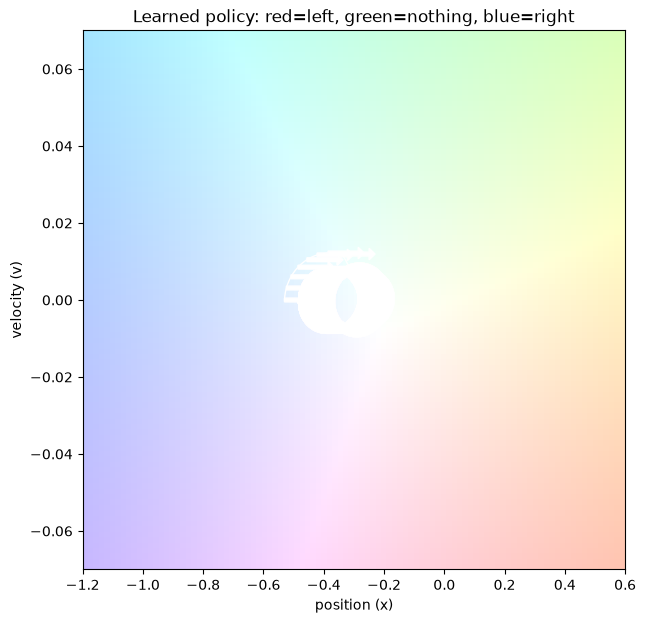

In [ ]:
def visualize_mountain_car(env, agent):
    core = env.unwrapped
    xs = np.linspace(core.min_position, core.max_position, 100)
    vs = np.linspace(-core.max_speed, core.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = agent.predict_proba(norm_obs(grid_flat))
    probs = probs.reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    probs = probs / probs.max(axis=-1, keepdims=True)

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(probs, extent=(core.min_position, core.max_position,
                             -core.max_speed, core.max_speed), aspect="auto")
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    b = rollout_batch([env], agent, t_max=10_000, greedy=True)
    states  = b["S"][0]
    actions = b["A"][0]
    ax.plot(states[:, 0], states[:, 1], color="white", lw=1)

    for (x, v), a in zip(states[::3], actions[::3]):
        if a in (0, 2):
            ax.arrow(x, v, -0.1 if a == 0 else 0.1, 0,
                     color="white", head_length=0.02)
            
with gym.make("MountainCar-v0").env as env:
    visualize_mountain_car(env, make_agent())

Следующую главу я постараюсь доделать в ближайшее время

### Bonus tasks

* __2.3 bonus__ (0.2 pts) Try to find a network architecture and training params that solve __both__ environments above. 

* __2.4 bonus__ (0.3 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 0.3 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.